## Plane Wing Oscillations
#### Saran Kaba (sk65556)

### The average flight experiences 30 minutes of turbulence which is factored into the creation of planes, specifically their wings(Chuinkam, 2026). To counteract the effects of turbulence, the wings are designed to be flexible and bend when experiencing stress. This causes oscillations

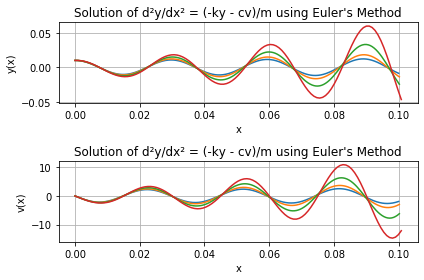

In [113]:
import numpy as np
import matplotlib.pyplot as plt
# Define the parameters
k = 9772200.0        # Spring constant/bending stiffness
step = [.0001, .0003, .0006,.0009]       # Step size
x_start = 0    # Start of the interval
x_end = .1     # End of the interval
y_0 = 0.01      # Initial condition for y
v_0 = 0.0      # Initial condition for dy/dx
m=217.7          #Mass of the wing (kg)
c= 0.0        #Damping coefficient

#plt.figure(figsize=(10, 5))
fig,(one,two)=plt.subplots(2,1)

for j in h:
    # Create arrays to store x, y, and v values
    x_values = np.arange(x_start, x_end + j, j)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))
    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    # Euler's Method loop
    for i in range(1, len(x_values)):
        # Current values
        x_n = x_values[i - 1]
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]    
        # Update equations
        y_values[i] = y_n + j * v_n
        v_values[i] = v_n + j * (-k * y_n-c*v_n)/m

    # Plot the results
    one.plot(x_values, y_values, label=f'Position y(x) at h={j}')
    two.plot(x_values, v_values, label=f'Velocity v(x) at h={j}')
one.set_xlabel('x')
two.set_xlabel('x')
one.set_ylabel('y(x)')
two.set_ylabel('v(x)')
one.set_title('Solution of d²y/dx² = (-ky - cv)/m using Euler\'s Method')
two.set_title('Solution of d²y/dx² = (-ky - cv)/m using Euler\'s Method')
#one.legend()
#two.legend()
one.grid(True)
two.grid(True)
plt.tight_layout()
plt.show()

In [115]:
def stabilitychecker(h,k,m,c):
    A=[[1,h],[-k*h/m,1-c*h/m]]
    eigVa,eigVe=np.linalg.eig(A)
    print(eigVa)
    print(np.abs(eigVa))
    print(np.max(np.abs(eigVa)))
    if np.all(np.abs(eigVa)<=1+1e-3):
        re="Solution is Stable"
    else:
        re="Solution is Unstable"
    return re

for j in h:
    print(f"for h= {j} the {stabilitychecker(j,k,m,c)}")

[1.+0.02118688j 1.-0.02118688j]
[1.00022442 1.00022442]
1.0002244167110825
for h= 0.0001 the Solution is Stable
[1.+0.06356063j 1.-0.06356063j]
[1.00201794 1.00201794]
1.0020179409896948
for h= 0.0003 the Solution is Unstable
[1.+0.12712127j 1.-0.12712127j]
[1.00804753 1.00804753]
1.008047526786763
for h= 0.0006 the Solution is Unstable
[1.+0.1906819j 1.-0.1906819j]
[1.01801748 1.01801748]
1.0180174785272826
for h= 0.0009 the Solution is Unstable


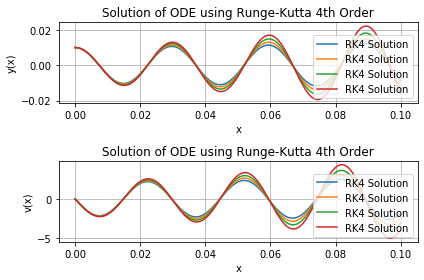

In [70]:
# Define the ODE function, for example, dy/dt = f(t, y) = -2 * t * y^2
def f(c,vr,k,yr):
    return (-c*vr-k*yr)/m
# Implement the RK4 method
def runge_kutta_4(f, y0, x0, xf, h,v0):
    # Create an array for time steps
    x_values = np.arange(x0, xf + h, h)
    y_values = np.zeros(len(x_values)) 
    v_values=np.zeros(len(x_values))
    # Set the initial condition
    y_values[0] = y0
    v_values[0]=v0
    # Perform the RK4 iteration
    for i in range(1, len(x_values)):
        y = y_values[i - 1]
        v = v_values[i - 1]        
        k1 = h*v
        r1=h * f(c,v,k,y)
        k2 = h * (v+h/2*r1)
        r2=h * f(c,v+h/2*r1,k,y+h/2*k1)
        k3 =h*(v+h/2*r2)
        r3=h * f(c,v+h/2*r2,k,y+h/2*k2)
        k4 =h*(v+h*r3)
        r4=h * f(c,v+h*r3,k,y+h*k3)
        # Update y based on the RK4 formula
        y_values[i] = y + (k1 + 2 * k2 + 2 * k3 + k4) / 6
        v_values[i]=v+(r1+2*r2+2*r3+r4)/6
    return x_values,y_values, v_values
# Set initial conditions and parameters
y0 = 0.01  # Initial value of y
x0 = 0.0  # Initial time
xf = 0.1  # Final time
v0=0.0    # Initial value of dy/dx
h = [.0001, .0002, .0003,.0004]   # Step size

fig,(oner,twor)=plt.subplots(2,1)

for j in h:
    # Run the RK4 solver
    xr_values,yr_values, vr_values = runge_kutta_4(f, y0, x0, xf, j,v0)
    # Plot the results
    
    
    oner.plot(xr_values, yr_values, label='RK4 Solution')
    twor.plot(xr_values, vr_values, label='RK4 Solution')
oner.set_xlabel('x')
oner.set_ylabel('y(x)')
oner.set_title('Solution of ODE using Runge-Kutta 4th Order')
oner.legend()
oner.grid(True)

twor.set_xlabel('x')
twor.set_ylabel('v(x)')
twor.set_title('Solution of ODE using Runge-Kutta 4th Order')
twor.legend()
twor.grid(True)

plt.tight_layout()
plt.show()

In [110]:
def rk4_stability_function(h,k,m,c):
    A=[[1,h],[-k*h/m,1-c*h/m]]
    eigVa,eigVe=np.linalg.eig(A)
    print(eigVa)
    return 1 + z + (z**2) / 2 + (z**3) / 6 + (z**4) / 24
    
    if np.all(np.abs(eigVa)-1<=1):
        re="Solution is Stable"
    else:
        re="Solution is Unstable"
    return re
    
for j in h:
    print(rk4_stability_function(j,k,m,c))

[1.+0.02118688j 1.-0.02118688j]
None
[1.+0.06356063j 1.-0.06356063j]
None
[1.+0.12712127j 1.-0.12712127j]
None
[1.+0.1906819j 1.-0.1906819j]
None
